# 03 · Results for the paper

- **A.** SmolLM2 baseline (CausalCoT run on the easy file), rescored with the tolerant yes/no parser.
- **B.** Commonsense-alignment results from notebook 02: accuracy by variant (H1), P(Yes) shift on matched pairs (H1b), accuracy by rung (H2), answer bias, topology, failure graphs.
- **C.** Export: LaTeX table rows and PDF figures into the paper folder.
- **D.** CausalCoT vs direct on the same items: hypotheses, truncated reasoning, trace reader, export.

In [2]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causal_evaluation.evaluation.failure_graph import draw_failure_graph, failure_graph
from causal_evaluation.evaluation.stats import extract_yes_no
from causal_evaluation.evaluation.variant_analysis import (
    load_scored,
    nonsense_gap,
    p_yes_shift,
    paired_accuracy_gap,
    rate_table,
)

INTERIM = Path(os.environ.get("CE_INTERIM", ROOT / "data" / "interim"))
PAPER_DIR = Path(os.environ.get("CE_PAPER_DIR", ROOT.parent / "tesispp" / "cadis-extended-abstract"))
FIG_DIR, TAB_DIR = PAPER_DIR / "figures", PAPER_DIR / "tables"
for folder in (FIG_DIR, TAB_DIR):
    folder.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)


def short(model):
    return model.split("/")[-1].split(":")[0]

## A · SmolLM2 baseline, rescored

In [ ]:
sample_full = pd.read_json(INTERIM / "sample-full.jsonl", lines=True, dtype={"question_id": str})
responses = pd.read_json(INTERIM / "responses-smollm2-full.jsonl", lines=True, dtype={"question_id": str})
responses["text"] = responses["response"].map(lambda r: r.get("text") or "")
responses["error"] = responses["response"].map(lambda r: r.get("error"))

base = responses.merge(
    sample_full[["question_id", "answer", "causal_level", "meta"]], on="question_id", validate="one_to_one"
)
base["answer"] = base["answer"].str.strip().str.lower()
base["story_kind"] = base["meta"].map(lambda m: "nonsense" if str(m["story_id"]).startswith("nonsense") else "named")
base["parsed"] = base["text"].map(extract_yes_no)
base["status"] = np.select([base["error"].notna(), base["parsed"].isna()], ["error", "unparsed"], "parsed")
base["correct_exact"] = base["text"].str.strip().str.casefold() == base["answer"]
base["correct_parsed"] = base["parsed"] == base["answer"]
base["is_yes"] = base["parsed"] == "yes"

base["status"].value_counts()

In [ ]:
baseline = pd.DataFrame(
    {
        "exact_match": base.groupby("causal_level")["correct_exact"].mean(),
        "tolerant_parser": base.groupby("causal_level")["correct_parsed"].mean(),
        "n": base.groupby("causal_level").size(),
    }
)
baseline.loc["overall"] = [base["correct_exact"].mean(), base["correct_parsed"].mean(), len(base)]
baseline

In [ ]:
parsed = base[base["status"] == "parsed"]
display(rate_table(parsed, ["causal_level"], flag="correct_parsed"))
display(rate_table(parsed, ["story_kind"], flag="correct_parsed"))
print(f"Yes rate among parsed answers: {parsed['is_yes'].mean():.3f} (answers are 50/50)")

## B · Commonsense alignment

In [3]:
USE_SMOKE = False  # True only to test this notebook with the -smoke files from notebook 02
result_paths = [
    p
    for p in sorted(INTERIM.glob("logprobs-*.jsonl"))
    if p.name.endswith("-smoke.jsonl") == USE_SMOKE and "causal_cot" not in p.name
]
print("\n".join(p.name for p in result_paths))
df = load_scored(INTERIM / "variants-sample.jsonl", result_paths)
df["is_yes"] = df["pred"] == "yes"

MODEL_ORDER = ("SmolLM2", "Qwen2.5-1.5B", "Qwen2.5-7B", "Phi-3.5")
VARIANT_ORDER = ("commonsense", "noncommonsense", "anticommonsense")
VARIANT_LABELS = {
    "commonsense": "commonsense",
    "noncommonsense": "nonsensical",
    "anticommonsense": "anti-commonsensical",
}


def model_sort_key(model):
    label = short(model)
    return next((i for i, prefix in enumerate(MODEL_ORDER) if label.startswith(prefix)), len(MODEL_ORDER))


models = sorted(df["model"].unique(), key=model_sort_key)
display(
    df.groupby("model").agg(
        items=("item_id", "size"),
        median_answer_mass=("answer_mass", "median"),
        yes_rate=("is_yes", "mean"),
    ).reindex(models)
)


logprobs-Phi-3.5-mini-instruct.jsonl
logprobs-Qwen2.5-1.5B-Instruct.jsonl
logprobs-Qwen2.5-7B-Instruct.jsonl
logprobs-SmolLM2-1.7B-Instruct.jsonl


,items,median_answer_mass,yes_rate
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,3000,0.991,6.667e-04
Qwen/Qwen2.5-1.5B-Instruct,3000,1.000,4.973e-01
Qwen/Qwen2.5-7B-Instruct,3000,1.000,4.790e-01
microsoft/Phi-3.5-mini-instruct,3000,1.000,3.273e-01


### Accuracy by variant

In [7]:
acc = rate_table(df, ["model", "variant"])
acc_table = acc.pivot(index="model", columns="variant", values="rate").reindex(models)
acc_table = acc_table.reindex(columns=VARIANT_ORDER).rename(columns=VARIANT_LABELS)
acc_table

variant,commonsense,nonsensical,anti-commonsensical
model,,,
HuggingFaceTB/SmolLM2-1.7B-Instruct,0.502,0.500,0.500
Qwen/Qwen2.5-1.5B-Instruct,0.515,0.534,0.501
Qwen/Qwen2.5-7B-Instruct,0.571,0.556,0.596
microsoft/Phi-3.5-mini-instruct,0.586,0.552,0.572


### H1 · Anti-commonsensical gap on matched pairs, and nonsensical gap

In [ ]:
h1_paired = paired_accuracy_gap(df)
h1_paired

In [ ]:
h1_nonsense = nonsense_gap(df)
h1_nonsense

### H1b · P(Yes) shift on matched relational items (commonsense minus anticommonsense)

In [ ]:
h1b = p_yes_shift(df)
h1b

### H2 · Accuracy by rung

In [ ]:
h2 = rate_table(df, ["model", "rung"])
h2.pivot(index="model", columns="rung", values="rate")

### Answer bias and topology

In [ ]:
yes_rates = rate_table(df, ["model", "variant"], flag="is_yes")
display(yes_rates.pivot(index="model", columns="variant", values="rate"))
rate_table(df, ["model", "graph_id"]).pivot(index="graph_id", columns="model", values="rate")

## C · Figures and table for the paper

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 3))
variant_offsets = np.linspace(-0.22, 0.22, len(VARIANT_ORDER))
for offset, variant in zip(variant_offsets, VARIANT_ORDER, strict=True):
    rows = acc[acc["variant"] == variant].set_index("model").reindex(models)
    ax.errorbar(
        np.arange(len(models)) + offset,
        rows["rate"],
        yerr=[rows["rate"] - rows["lo"], rows["hi"] - rows["rate"]],
        fmt="o",
        capsize=2,
        label=VARIANT_LABELS[variant],
    )
ax.axhline(0.5, color="gray", lw=0.8, ls="--", label="chance")
ax.set_xticks(np.arange(len(models)), [short(m) for m in models], rotation=15, fontsize=7)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.3, 0.75)
ax.legend(fontsize=7, frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_by_variant.pdf")

In [ ]:
for model in models:
    nodes, edges = failure_graph(df[df["model"] == model])
    fig, ax = plt.subplots(figsize=(7, 4))
    draw_failure_graph(nodes, edges, ax=ax, title=short(model))
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"failure_graph_{short(model)}.pdf")
    display(edges.sort_values("lift", ascending=False).head(8))

In [ ]:
def cell(row):
    return f"{row.rate:.2f} [{row.lo:.2f}, {row.hi:.2f}]"


shift_yes = h1b[h1b["answer"] == "yes"].set_index("model")
lines = []
for model in models:
    cells = {r.variant: cell(r) for r in acc[acc["model"] == model].itertuples()}
    p_yes = (
        f"{shift_yes.loc[model, 'p_yes_common']:.2f} / {shift_yes.loc[model, 'p_yes_anti']:.2f}"
        if model in shift_yes.index
        else "--"
    )
    name = short(model).replace("_", r"\_")
    lines.append(
        f"{name} & {cells.get('commonsense', '--')} & {cells.get('noncommonsense', '--')} & "
        f"{cells.get('anticommonsense', '--')} & {p_yes} \\\\"
    )
(TAB_DIR / "variants_rows.tex").write_text("\n".join(lines) + "\n")
print("model order:", " -> ".join(short(model) for model in models))
print("columns: model & commonsense & nonsensical & anti-commonsensical & P(Yes) common / anti")
print("\n".join(lines))

## D · CausalCoT vs direct on the same items

The CausalCoT run covers a balanced subset (150 matched pairs + 150 nonsense items per model). Every comparison here restricts the direct results to those same items. Model labels read `<model> | direct` and `<model> | causal_cot`.

Result files used:

In [4]:
SAMPLE_PATH = INTERIM / "variants-sample.jsonl"
DIRECT_PATHS = result_paths
COT_PATHS = [p for p in sorted(INTERIM.glob("logprobs-*-causal_cot*.jsonl")) if p.name.endswith("-smoke.jsonl") == USE_SMOKE]
for path in [SAMPLE_PATH, *DIRECT_PATHS, *COT_PATHS]:
    print(path)

both = load_scored(SAMPLE_PATH, DIRECT_PATHS + COT_PATHS)
both["base"] = both["model"].str.replace("-causal_cot", "", regex=False).map(short)
both["strategy"] = np.where(both["model"].str.endswith("-causal_cot"), "causal_cot", "direct")
cot_ids = set(both.loc[both["strategy"] == "causal_cot", "item_id"])
same = both[both["item_id"].isin(cot_ids)].copy()
same["model"] = same["base"] + " | " + same["strategy"]
same["is_yes"] = same["pred"] == "yes"
cot = same[same["strategy"] == "causal_cot"].copy()
same.groupby("model").size()

/Users/laudima/Repositorios/causal-evaluation/data/interim/variants-sample.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Phi-3.5-mini-instruct.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Qwen2.5-1.5B-Instruct.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Qwen2.5-7B-Instruct.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-SmolLM2-1.7B-Instruct.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Phi-3.5-mini-instruct-causal_cot.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Qwen2.5-1.5B-Instruct-causal_cot.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-Qwen2.5-7B-Instruct-causal_cot.jsonl
/Users/laudima/Repositorios/causal-evaluation/data/interim/logprobs-SmolLM2-1.7B-Instruct-causal_cot.jsonl


model
Phi-3.5-mini-instruct | causal_cot    450
Phi-3.5-mini-instruct | direct        450
Qwen2.5-1.5B-Instruct | causal_cot    450
Qwen2.5-1.5B-Instruct | direct        450
Qwen2.5-7B-Instruct | causal_cot      450
Qwen2.5-7B-Instruct | direct          450
SmolLM2-1.7B-Instruct | causal_cot    450
SmolLM2-1.7B-Instruct | direct        450
dtype: int64

### Accuracy by variant

In [5]:
acc_same = rate_table(same, ["model", "variant"])
acc_same_table = acc_same.pivot(index="model", columns="variant", values="rate")
same_model_order = [
    f"{short(model)} | {strategy}"
    for model in models
    for strategy in ("direct", "causal_cot")
]
acc_same_table = acc_same_table.reindex(same_model_order).rename(columns=VARIANT_LABELS)
acc_same_table

variant,anti-commonsensical,commonsense,nonsensical
model,,,
SmolLM2-1.7B-Instruct | direct,0.500,0.500,0.500
SmolLM2-1.7B-Instruct | causal_cot,0.487,0.493,0.500
Qwen2.5-1.5B-Instruct | direct,0.460,0.473,0.500
Qwen2.5-1.5B-Instruct | causal_cot,0.520,0.540,0.513
Qwen2.5-7B-Instruct | direct,0.620,0.560,0.533
Qwen2.5-7B-Instruct | causal_cot,0.647,0.613,0.673
Phi-3.5-mini-instruct | direct,0.567,0.587,0.553
Phi-3.5-mini-instruct | causal_cot,0.620,0.587,0.567


### H1 · Anti-commonsensical gap on matched pairs, and nonsensical gap

In [ ]:
h1_same = paired_accuracy_gap(same)
h1_same

In [ ]:
nonsense_gap(same)

### H1b · P(Yes) shift on matched relational items (commonsense minus anticommonsense)

In [ ]:
p_yes_shift(same)

### H2 (by rung) and answer bias

In [ ]:
display(rate_table(same, ["model", "rung"]).pivot(index="model", columns="rung", values="rate"))
rate_table(same, ["model", "variant"], flag="is_yes").pivot(index="model", columns="variant", values="rate")

### Truncated reasoning

`reasoning_truncated` means the trace hit `max_new_tokens` before the model finished, so the final Yes/No was given on incomplete reasoning. If truncation is similar across variants it does not bias H1, but it lowers accuracy.

In [ ]:
display(cot.pivot_table(index="base", columns="variant", values="reasoning_truncated", aggfunc="mean"))
display(cot.pivot_table(index="query_type", columns="base", values="reasoning_truncated", aggfunc="mean"))
cot.pivot_table(index="base", columns="reasoning_truncated", values="correct", aggfunc=["mean", "size"])

### Finished traces only (secondary check)

Keeps pairs where **both** members finished their reasoning. This is not a random subset (harder items truncate more often), so treat it as a robustness check, not the main result.

In [ ]:
finished = cot[~cot["reasoning_truncated"].astype(bool)]
pair_size = finished.groupby(["model", "pair_id"])["item_id"].transform("size")
display(paired_accuracy_gap(finished[pair_size == 2]))
rate_table(finished, ["model", "variant"]).pivot(index="model", columns="variant", values="rate")

### Reading reasoning traces

`show_trace` prints the prompt the model saw, its reasoning, P(Yes) and the correct answer. Filter by model (substring), variant, correctness or truncation. `show_pair` prints both members of a matched pair for one model, to compare how the renamed variable changed the reasoning.

In [ ]:
from causal_evaluation.models.logprob import item_text


def _print_row(row, max_chars):
    print(f"=== {row['model']} | {row['item_id']} | {row['query_type']} (rung {row['rung']}) | "
          f"correct answer: {row['answer']} | P(Yes) = {row['p_yes']:.2f} | "
          f"{'CORRECT' if row['correct'] else 'WRONG'}{' | TRUNCATED' if row['reasoning_truncated'] else ''}")
    print("--- prompt\n" + item_text(row))
    print("--- reasoning\n" + str(row["reasoning"])[:max_chars] + "\n")


def show_trace(model="", variant=None, correct=None, truncated=None, n=1, seed=0, max_chars=3000):
    rows = cot[cot["model"].str.contains(model, regex=False)]
    if variant is not None:
        rows = rows[rows["variant"] == variant]
    if correct is not None:
        rows = rows[rows["correct"] == correct]
    if truncated is not None:
        rows = rows[rows["reasoning_truncated"].astype(bool) == truncated]
    print(f"{len(rows)} matching traces")
    for _, row in rows.sample(min(n, len(rows)), random_state=seed).iterrows():
        _print_row(row, max_chars)


def show_pair(model, pair_id=None, seed=0, max_chars=2000):
    rows = cot[cot["model"].str.contains(model, regex=False) & cot["pair_id"].notna()]
    if pair_id is None:
        pair_id = rows["pair_id"].sample(1, random_state=seed).iloc[0]
    for _, row in rows[rows["pair_id"] == pair_id].sort_values("variant", ascending=False).iterrows():
        _print_row(row, max_chars)


show_trace("Qwen2.5-7B", variant="anticommonsense", correct=False)

In [ ]:
show_pair("Phi-3.5")

### Made-up data (heuristic)

Deterministic counterfactuals give no probabilities in the prompt. A trace that nonetheless writes probability values such as `P(...) = 0.3` has invented data. This is a rough text filter, so read the flagged traces before quoting a rate.

In [ ]:
cot["prompt_has_numbers"] = cot["given_info"].str.contains(r"\d")
cot["trace_states_probabilities"] = cot["reasoning"].fillna("").str.contains(r"P\([^)]*\)\s*=\s*0?\.\d")
cot["invented_numbers"] = ~cot["prompt_has_numbers"] & cot["trace_states_probabilities"]
no_numbers = cot[~cot["prompt_has_numbers"]]
display(no_numbers.groupby(["base", "query_type"])["invented_numbers"].agg(["mean", "size"]))
flagged = cot[cot["invented_numbers"]]
if len(flagged):
    _print_row(flagged.iloc[0], 2500)

### Export: direct vs CausalCoT figure and table rows

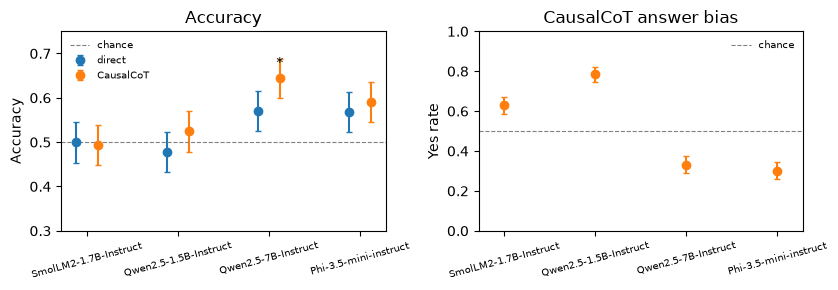

In [9]:
bases = [short(model) for model in models if short(model) in set(same["base"])]
acc_overall = rate_table(same, ["base", "strategy"])
yes_overall = rate_table(cot, ["base"], flag="is_yes").set_index("base").reindex(bases)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3), sharex=True)
accuracy_offsets = {"direct": -0.12, "causal_cot": 0.12}
for strategy, offset in accuracy_offsets.items():
    rows = acc_overall[acc_overall["strategy"] == strategy].set_index("base").reindex(bases)
    axes[0].errorbar(
        np.arange(len(bases)) + offset,
        rows["rate"],
        yerr=[rows["rate"] - rows["lo"], rows["hi"] - rows["rate"]],
        fmt="o",
        capsize=2,
        label="CausalCoT" if strategy == "causal_cot" else "direct",
    )
qwen_7b = next(i for i, base in enumerate(bases) if base.startswith("Qwen2.5-7B"))
qwen_7b_base = bases[qwen_7b]
qwen_7b_cot = acc_overall.set_index(["base", "strategy"]).loc[(qwen_7b_base, "causal_cot"), "rate"]
axes[0].annotate("*", (qwen_7b + accuracy_offsets["causal_cot"], qwen_7b_cot), xytext=(0, 8),
                 textcoords="offset points", ha="center", fontsize=10)
axes[0].axhline(0.5, color="gray", lw=0.8, ls="--", label="chance")
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.3, 0.75)
axes[0].legend(fontsize=7, frameon=False)

axes[1].errorbar(
    np.arange(len(bases)),
    yes_overall["rate"],
    yerr=[yes_overall["rate"] - yes_overall["lo"], yes_overall["hi"] - yes_overall["rate"]],
    fmt="o",
    capsize=2,
    color="tab:orange",
)
axes[1].axhline(0.5, color="gray", lw=0.8, ls="--", label="chance")
axes[1].set_title("CausalCoT answer bias")
axes[1].set_ylabel("Yes rate")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7, frameon=False)

for ax in axes:
    ax.set_xticks(np.arange(len(bases)), bases, rotation=15, fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_direct_vs_cot.pdf")

In [ ]:
gaps = h1_same.set_index("model")
trunc = cot.groupby("base")["reasoning_truncated"].mean()
rows_tex = []
for base in bases:
    d, c = gaps.loc[f"{base} | direct"], gaps.loc[f"{base} | causal_cot"]
    acc_d = acc_overall.set_index(["base", "strategy"]).loc[(base, "direct"), "rate"]
    acc_c = acc_overall.set_index(["base", "strategy"]).loc[(base, "causal_cot"), "rate"]
    name = base.replace("_", r"\_")
    rows_tex.append(
        f"{name} & {acc_d:.2f} & {acc_c:.2f} & "
        f"{d.gap:+.3f} [{d.gap_lo:+.2f}, {d.gap_hi:+.2f}] & "
        f"{c.gap:+.3f} [{c.gap_lo:+.2f}, {c.gap_hi:+.2f}] & {trunc[base]:.2f} \\\\"
    )
(TAB_DIR / "cot_rows.tex").write_text("\n".join(rows_tex) + "\n")
print("columns: model & acc direct & acc CausalCoT & gap direct [CI] & gap CausalCoT [CI] & truncated")
print("\n".join(rows_tex))

## Question-only priors: do the names carry a prior, and does the context override it?

Notebook 02's question-only run asks each matched item **without the background or the given probabilities**, so its P(Yes) is the model's prior for the question as worded. Two questions:

1. **Prior gap.** Commonsensical minus anti-commonsensical P(Yes) with no context. The main test assumes that the anti-commonsensical names carry a prior against the stated relation. If a model shows no prior gap, the test cannot tell the hypotheses apart for that model, and the paper should say so plainly.
2. **Prior vs. structure.** Per model, `logit P(Yes | context) ~ 1 + logit P(Yes | question only) + correct answer`. `b_prior` says how much the in-context answer follows the prior; `b_answer` how much it follows the given structure. The within-pair slope regresses the context-logit difference between the two names on their prior-logit difference: the share of a name's prior that passes through the given graph and numbers.

Reading rule (band ±0.04, as in Sect. 4.6): a large prior gap with no in-context gap means the given context overrides the names, which is a real finding. A prior gap near zero means the test is uninformative at this scale.

In [ ]:
from causal_evaluation.data.variants import RELATIONAL_QUERY_TYPES
from causal_evaluation.evaluation.prior_analysis import (
    interpret,
    join_prior,
    paired_gaps,
    prior_vs_structure,
)

PRIOR_PATHS = [
    p
    for p in sorted(INTERIM.glob("logprobs-*-question_only*.jsonl"))
    if p.name.endswith("-smoke.jsonl") == USE_SMOKE
]
print("\n".join(p.name for p in PRIOR_PATHS) or "No question-only files yet: run the last section of notebook 02.")
prior_df = load_scored(SAMPLE_PATH, PRIOR_PATHS)
display(
    prior_df.groupby("model").agg(
        items=("item_id", "size"),
        median_answer_mass=("answer_mass", "median"),
        yes_rate=("pred", lambda s: (s == "yes").mean()),
    )
)
direct_df = load_scored(SAMPLE_PATH, DIRECT_PATHS)
joined = join_prior(direct_df, prior_df)
joined.groupby("base").size()

In [ ]:
# 1. Prior gap vs in-context gap, on all pairs and on the relational query types (H1b set)
gaps_all = interpret(paired_gaps(joined))
gaps_rel = interpret(paired_gaps(joined, RELATIONAL_QUERY_TYPES))
display(gaps_all)
gaps_rel

In [ ]:
# 2. How much each in-context answer follows the prior vs the given structure
fit = prior_vs_structure(joined)
fit

In [ ]:
# Within-pair view: does the prior difference between the two names pass into the in-context answer?
bases = sorted(joined["base"].unique())
fig, axes = plt.subplots(1, len(bases), figsize=(2.2 * len(bases), 2.4), sharex=True, sharey=True, squeeze=False)
for ax, base in zip(axes[0], bases):
    wide = joined[joined["base"] == base].pivot_table(
        index="pair_id", columns="variant", values=["logit_prior", "logit_ctx"]
    ).dropna()
    d_prior = wide[("logit_prior", "commonsense")] - wide[("logit_prior", "anticommonsense")]
    d_ctx = wide[("logit_ctx", "commonsense")] - wide[("logit_ctx", "anticommonsense")]
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.scatter(d_prior, d_ctx, s=4, alpha=0.5)
    slope = fit.set_index("model").loc[base, "within_pair_slope"]
    xs = np.linspace(d_prior.min(), d_prior.max(), 2)
    ax.plot(xs, slope * xs, color="black", lw=1)
    ax.set_title(f"{short(base)}\nslope {slope:.2f}", fontsize=7)
    ax.set_xlabel("prior logit gap (comm. - anti-C.)", fontsize=6)
axes[0][0].set_ylabel("in-context logit gap", fontsize=6)
fig.tight_layout()
fig.savefig(FIG_DIR / "prior_vs_context.pdf")